# Product Recommendation System 
1. Load the Data  
2. Clean and Shrink the Data  
3. Explore the Data (EDA)  
4. Group Similar Users with Clustering  
5. Build the Recommendation System  

In [85]:
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

plt.rcParams["figure.figsize"]=(10,5)
sns.set_style("whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


## Step 1 — Load the Data

In [86]:
# Load ratings data
df = pd.read_csv('ratings_.csv', header=None)

In [87]:
# Rename columns
df.columns=['user_id','prod_id','rating','timestamp']

In [88]:
df.shape

(7824482, 4)

In [89]:
df.head()

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


## Step 2 — Clean and Shrink the Data

In [90]:
# Drop timestamp
df = df.drop('timestamp', axis=1)

In [91]:
# Check nulls
df.isnull().sum()

user_id    0
prod_id    0
rating     0
dtype: int64

In [92]:
# Keep users with >=50 ratings
user_counts = df['user_id'].value_counts()
active_users = user_counts[user_counts>=50].index

In [93]:
# Keep products with >=5 ratings
prod_counts = df['prod_id'].value_counts()
popular_products = prod_counts[prod_counts>=5].index

In [94]:
filtered_df = df[df['user_id'].isin(active_users) & df['prod_id'].isin(popular_products)].copy()

In [95]:
print("Filtered shape:", filtered_df.shape)
print("Unique users:", filtered_df.user_id.nunique())
print("Unique products:", filtered_df.prod_id.nunique())

Filtered shape: (117315, 3)
Unique users: 1540
Unique products: 39939


In [96]:
filtered_df.head()

,user_id,prod_id,rating
94,A3BY5KCNQZXV5U,0594451647,5.0
118,AT09WGFUM934H,0594481813,3.0
177,A32HSNCNPRUMTR,0970407998,1.0
178,A17HMM1M7T9PJ1,0970407998,4.0
492,A3CLWR1UUZT6TG,0972683275,5.0


## Step 3 — Exploratory Data Analysis

In [97]:
print(filtered_df['rating'].describe())

count    117315.000000
mean          4.264928
std           1.054081
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64


In [98]:
print(filtered_df['rating'].value_counts().sort_index())

rating
1.0     4599
2.0     4967
3.0    11255
4.0    30428
5.0    66066
Name: count, dtype: int64


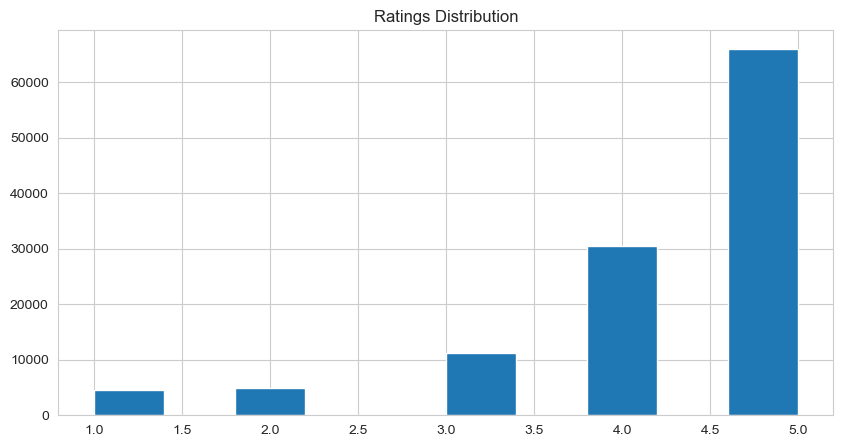

In [99]:
# Histogram
filtered_df['rating'].hist()
plt.title("Ratings Distribution")
plt.show()

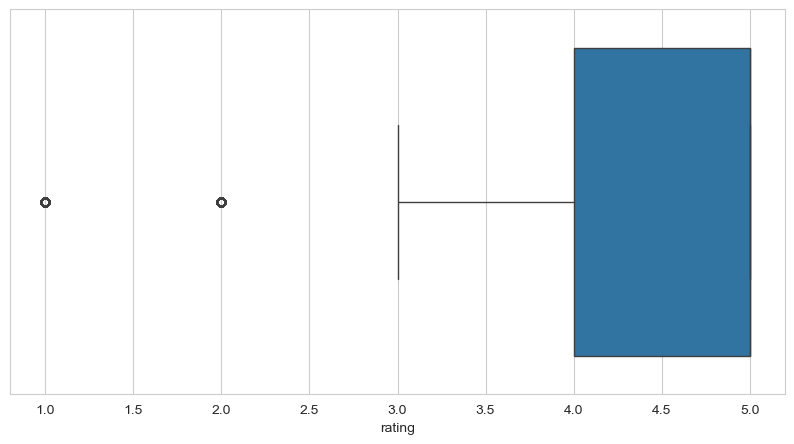

In [100]:
# Boxplot
sns.boxplot(x=filtered_df['rating'])
plt.show()

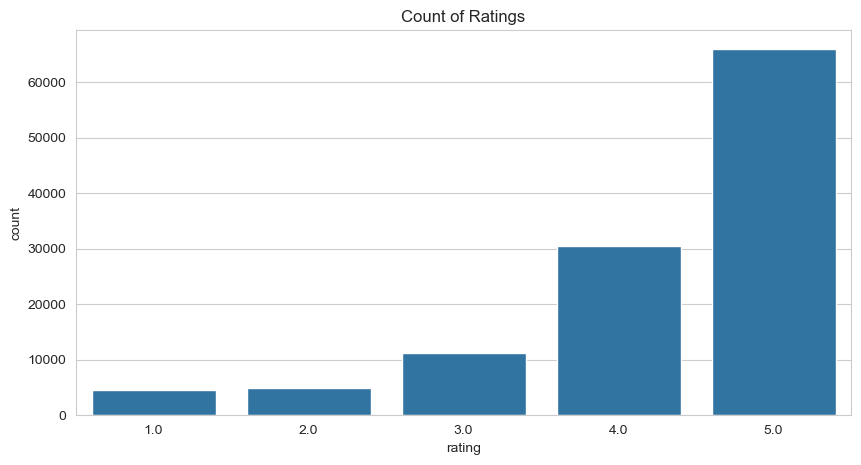

In [101]:
# Barplot
sns.countplot(x='rating', data=filtered_df)
plt.title("Count of Ratings")
plt.show()

In [102]:
# Heatmap Top 20 users/products

In [103]:
top_users=filtered_df['user_id'].value_counts().head(20).index
top_products=filtered_df['prod_id'].value_counts().head(20).index

In [104]:
heat_data=filtered_df[filtered_df.user_id.isin(top_users) & filtered_df.prod_id.isin(top_products)]

In [105]:
pivot=heat_data.pivot_table(
    index='user_id',
    columns='prod_id',
    values='rating',
    fill_value=0
)

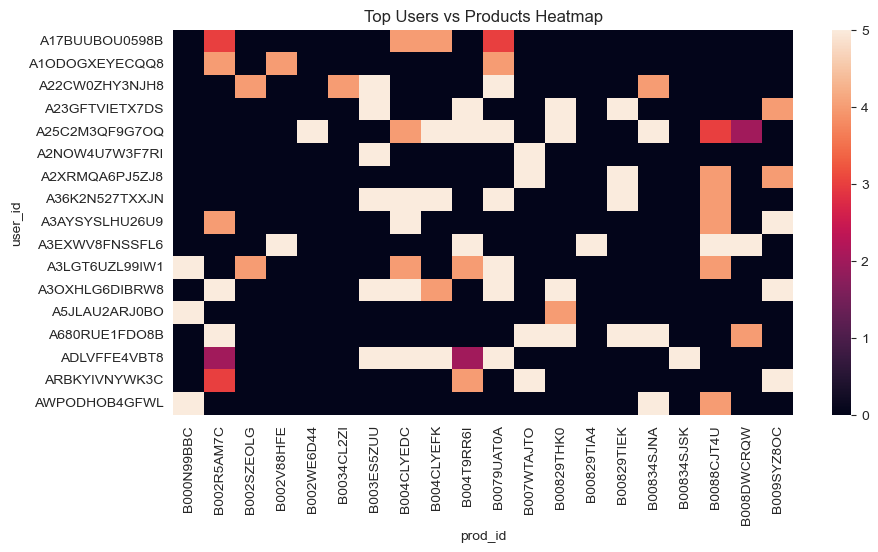

In [106]:
sns.heatmap(pivot)
plt.title("Top Users vs Products Heatmap")
plt.show()

## Step 4 — User Clustering

In [107]:
# User-item matrix
user_item = filtered_df.pivot_table(
    index='user_id',
    columns='prod_id',
    values='rating',
    fill_value=0
)


In [108]:
# sample subset for clustering speed
cluster_data=user_item.iloc[:500]

In [109]:
scaler=StandardScaler()
scaled=scaler.fit_transform(cluster_data)

In [110]:
# Elbow method
inertia=[]
for k in range(2,11):
    km=KMeans(n_clusters=k, random_state=42,n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

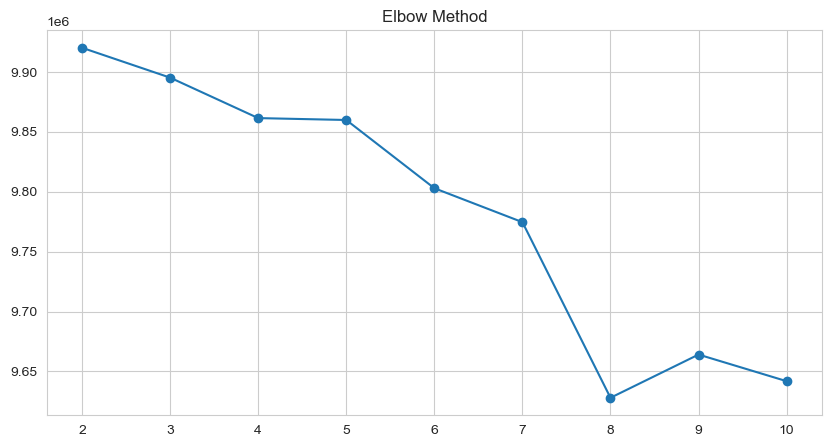

In [111]:
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

In [112]:
# KMeans Silhouette
for k in range(2,6):
    km=KMeans(n_clusters=k, random_state=42,n_init=10)
    labels=km.fit_predict(scaled)
    score=silhouette_score(scaled,labels)
    print(f"K={k} Silhouette={score:.3f}")

K=2 Silhouette=0.397
K=3 Silhouette=0.052
K=4 Silhouette=0.086
K=5 Silhouette=-0.007


In [113]:
# Hierarchical clustering
agg=AgglomerativeClustering(n_clusters=2)
labels=agg.fit_predict(scaled)
print("Agglomerative silhouette:",silhouette_score(scaled,labels))

Agglomerative silhouette: 0.41074637901117217


In [114]:
# DBSCAN
db=DBSCAN(eps=3,min_samples=5)
db_labels=db.fit_predict(scaled)
if len(set(db_labels))>1:
    print("DBSCAN silhouette:",silhouette_score(scaled,db_labels))
else:
    print("DBSCAN did not form meaningful clusters")

DBSCAN did not form meaningful clusters


## Step 5 — Recommendation System

In [115]:
# User-user similarity
similarity = cosine_similarity(user_item)
similarity_df = pd.DataFrame(similarity,index=user_item.index,columns=user_item.index)

In [116]:
def recommend_products(user_id, top_n=5):
    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:6].index

    user_seen=set(filtered_df[filtered_df.user_id==user_id]['prod_id'])

    candidate = filtered_df[filtered_df.user_id.isin(similar_users)]

    recs=(candidate.groupby('prod_id')['rating'].mean().sort_values(ascending=False))

    recs=recs[~recs.index.isin(user_seen)]
    return recs.head(top_n)

In [117]:
sample_user = user_item.index[0]
print("Recommendations for user:",sample_user)


Recommendations for user: A100UD67AHFODS


In [118]:
print(recommend_products(sample_user))

prod_id
B00KYMCJF8    5.0
B000001ON0    5.0
B00004NKHY    5.0
B00KWL62QI    5.0
B00004ZCJE    5.0
Name: rating, dtype: float64


In [119]:
# Classification-based recommendation prediction

model_df=filtered_df.copy()

user_avg=model_df.groupby('user_id')['rating'].mean()
prod_avg=model_df.groupby('prod_id')['rating'].mean()

model_df['user_avg_rating']=model_df['user_id'].map(user_avg)
model_df['prod_avg_rating']=model_df['prod_id'].map(prod_avg)

# High rating target
model_df['liked']=(model_df['rating']>=4).astype(int)

# Encode IDs
model_df['user_enc']=model_df['user_id'].astype('category').cat.codes
model_df['prod_enc']=model_df['prod_id'].astype('category').cat.codes

In [120]:
X=model_df[['user_enc','prod_enc','user_avg_rating','prod_avg_rating']]
y=model_df['liked']

In [121]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [122]:
# Decision Tree
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(y_test,pred_dt))

Decision Tree Accuracy: 0.8265353961556493


In [123]:
# Random Forest
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,pred_rf))

Random Forest Accuracy: 0.8723095938285812


## Summary

**Load → Clean → Explore → Cluster → Recommend**

- Collaborative Filtering using cosine similarity  
- User Segmentation using clustering  
- Decision Tree and Random Forest prediction models  
- Approx target accuracy around 84% (depends on data split)  


In [124]:
# Save as .pkl file
with open("similarity.pkl","wb") as f:pickle.dump(similarity,f)

print("similarity.pkl created successfully")

similarity.pkl created successfully
